In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

import spacy
from spacy_layout import spaCyLayout
from tika import parser
import pdfplumber

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [5]:
# We use the Sydbank Green Bond impact and allocation report 2025 to analyse in this example.
path = "/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/JPMC_ESFR_Methodology.pdf"

# The from_file() function of tika helps us to load the content of the document. (take ca. 30 sec)
# report = parser.from_file(path)

report_esfr_method = parser.from_file(path)

In [6]:
nlp = spacy.load('en_core_web_sm')
about_doc = nlp(report_esfr_method["content"])

In [7]:
sequences_esfr_method = list(map(str, about_doc.sents))
sequences_esfr_method

['\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n2024 Energy Supply Financing Ratio Methodology \n\n\nEnergy Supply \nFinancing Ratio \nMethodology \n\n2024\n\n\n\nContents \n1. INTRODUCTION 1 \n\n2.',
 'OVERVIEW OF OUR APPROACH 3 \n\n3. METHODOLOGY DETAIL 5 \n\n3.1 Energy Supply Boundary Definition 5 \n\n3.2 Scope of Financing Activities 6 \n\n3.3 Investment-Focused Portion of Financing 7 \n\n3.4 Low-Carbon / High-Carbon Allocation Approach 9 \n\n4. CY 2023',
 'ESFR CALCULATION 11 \n\n5.',
 'THE CASE FOR A TECHNOLOGY-ENABLING ESFR 12 \n\nAPPENDIX 13 \n\nAlignment with Carbon Compass® 13 \n\nAbbreviations 14 \n\nDisclaimer 15 \n\n\n\n1.',
 'Introduction \nThis paper provides details of the methodology currently used by JPMorgan Chase & Co. (“JPMC,” “we” or the “Firm”) \n\nfor calculating its Energy Supply Financing Ratio (ESFR).',
 'The ESFR is an example of a climate-related disclosure metric \n\nthat compares the amount of a ba

In [8]:
# "\n" signals a new line. We remove this so that the output looks better.
sentences_esfr_method = [x.replace("\n", "") for x in sequences_esfr_method]

# Remove all empty text, i.e. if the value is "", i.e are empty.
sentences_esfr_method = [x for x in sentences_esfr_method if x != ""]

# A sentence should start with upper case.
sentences_esfr_method = [x for x in sentences_esfr_method if x[0].isupper()]

sentences_esfr_method

['OVERVIEW OF OUR APPROACH 3 3. METHODOLOGY DETAIL 5 3.1 Energy Supply Boundary Definition 5 3.2 Scope of Financing Activities 6 3.3 Investment-Focused Portion of Financing 7 3.4 Low-Carbon / High-Carbon Allocation Approach 9 4. CY 2023',
 'ESFR CALCULATION 11 5.',
 'THE CASE FOR A TECHNOLOGY-ENABLING ESFR 12 APPENDIX 13 Alignment with Carbon Compass® 13 Abbreviations 14 Disclaimer 15 1.',
 'Introduction This paper provides details of the methodology currently used by JPMorgan Chase & Co. (“JPMC,” “we” or the “Firm”) for calculating its Energy Supply Financing Ratio (ESFR).',
 'The ESFR is an example of a climate-related disclosure metric that compares the amount of a bank’s financing — including direct financing provided through balance sheet lending, tax-oriented investments and facilitation of capital markets activity — supporting low-carbon-intensive and zero-carbon (referred to as "Low-Carbon") energy supply versus that supporting high-carbon-intensive and unabated fossil-based (r

In [9]:
import accelerate
import torchvision
from spacy_layout import spaCyLayout

nlp = spacy.blank("en")
layout = spaCyLayout(nlp)

In [10]:
doc = layout("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/JPMC_ESFR_Methodology.pdf")

[INFO] 2026-05-03 14:36:13,504 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-03 14:36:13,509 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-03 14:36:13,531 [RapidOCR] download_file.py:60: File exists and is valid: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-03 14:36:13,531 [RapidOCR] main.py:50: Using /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-05-03 14:36:13,695 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-05-03 14:36:13,696 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-05-03 14:36:13,698 [RapidOCR] download_file.py:60: File exists and is valid: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rapidocr/models/ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-05-03 14:36:13,698 [RapidOCR] main.py:50: Using /Libra

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


In [11]:
print(doc.text)

Energy Supply Financing Ratio Methodology

Contents

TABLE

12

13

1. Introduction

This paper provides details of the methodology currently used by JPMorgan Chase & Co. ('JPMC,' 'we' or the 'Firm') for calculating its Energy Supply Financing Ratio (ESFR). The ESFR is an example of a climate-related disclosure metric that compares the amount of a bank's financing - including direct financing provided through balance sheet lending, tax-oriented investments and facilitation of capital markets activity - supporting low-carbon-intensive and zero-carbon (referred to as "Low-Carbon") energy supply versus that supporting high-carbon-intensive and unabated fossil-based (referred to as "High-Carbon") energy supply. While this disclosure metric can provide more insight into the capital that we are providing, we are not targeting a specific ratio with which to align our financing.

The decision to disclose this ratio was made following engagement with our shareholders including the New York City

In [12]:
for table in doc._.tables:
    print(f"Table A:")
    print(table._.data)
    print("\n")

Table A:
                                                   0   1
0                                    1. INTRODUCTION   1
1                        2. OVERVIEW OF OUR APPROACH   3
2                              3. METHODOLOGY DETAIL   5
3              3.1 Energy Supply Boundary Definition   5
4                  3.2 Scope of Financing Activities   6
5        3.3 Investment-Focused Portion of Financing   7
6   3.4 Low-Carbon / High-Carbon Allocation Approach   9
7                        4. CY 2023 ESFR CALCULATION  11
8         5. THE CASE FOR A TECHNOLOGY-ENABLING ESFR  12
9                                           APPENDIX  13
10                    Alignment with Carbon Compass®  13
11                                     Abbreviations  14
12                                        Disclaimer  15


Table A:
                                                 ...                                              NOTES
0             ENERGY SUPPLY BOUNDARY DEFINITION  ...  Consistent with boundary

In [13]:
print(doc._.tables)

[TABLE, TABLE, TABLE, TABLE, TABLE, TABLE, TABLE, TABLE]


In [14]:
import pdfplumber

with pdfplumber.open("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/JPMC_ESFR_Methodology.pdf") as pdf:
    page_five = pdf.pages[6]
    print(page_five.extract_text())

3. Methodology Detail
This section provides a detailed discussion of key elements of our approach, including their underlying rationale and
impact on the ESFR. Our aim is to provide further insight into how we have constructed the ESFR and to provide an
insightful metric for our stakeholders that is also consistent with how we make financing decisions.
3.1 Energy Supply Boundary Definition
In establishing the exposure boundary for the ESFR, we considered what parts of the energy system should be
included. We are involved in financing a wide variety of energy-related activities that are relevant to maintaining the
affordability and security of the existing energy supply as well as enabling the transition to lower-carbon sources.
CATEGORY ACTIVITY NOTES
Solar (photovoltaic, concentrated solar power,
solar thermal)
Wind (onshore and offshore)
Geothermal
Low - and Zero-
Carbon Power Hydropower
Generation Marine
Nuclear
Bioenergy
Low-Carbon
Energy Supply Fossil-fuel power with CCUS
Electric

In [15]:
with pdfplumber.open("/Users/elisabethwatson/Birkbeck/PGC ADS/Module 3 Project/Datasets/GBTP 260201/JPMC_ESFR_Methodology.pdf") as pdf:
    page_five = pdf.pages[6]
    # Simple table extraction
    table = page_five.extract_table()
    for row in table:
        print(row)

['Low-Carbon\nEnergy Supply']
['High-Carbon\nEnergy Supply']


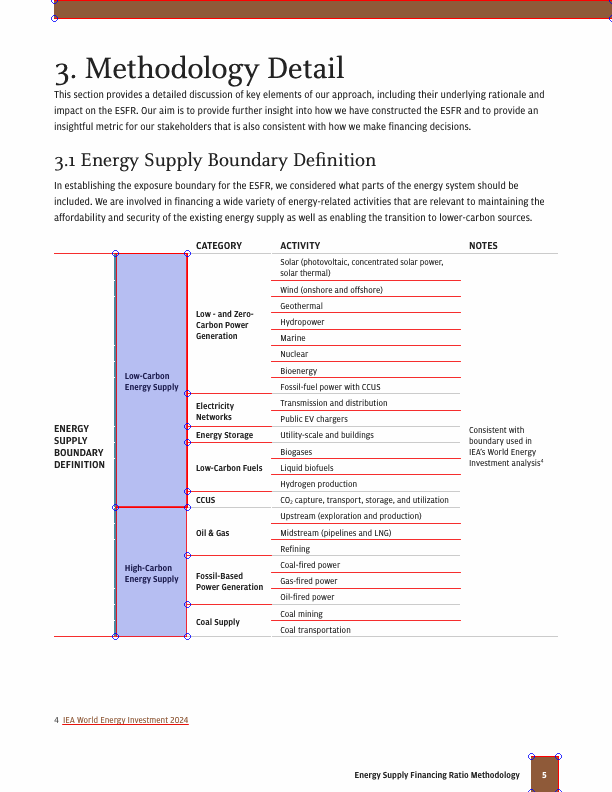

In [16]:
im = page_five.to_image()
im.debug_tablefinder()

In [17]:
### Load the models (takes ca. 1 min)
# Environmental model.
name = "ESGBERT/EnvironmentalBERT-environmental" # path to download from HuggingFace
# In simple words, the tokenizer prepares the text for the model and the model classifies the text-
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForSequenceClassification.from_pretrained(name)
# The pipeline combines tokenizer and model to one process.
pipe_env = pipeline("text-classification", model=model, tokenizer=tokenizer)

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
        pool_request.request
    )
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/httpcore/_sync/connection.py", line 101, in handle_request
    raise exc


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [18]:
# Classify subset of sentences.
# The padding and trunctuation parameters help us with classifying texts of different length.
sub_sentences_esfr_method = sentences_esfr_method[60:67] # takes around 20 seconds
env_esfr_method = pipe_env(sentences_esfr_method, padding=True, truncation=True)

# You might only want the labels.
env_labels_esfr_method = [x["label"] for x in env_esfr_method]

In [26]:
# Let's look at the results. We use a dataframe for this purpose.
data_env_esfr_method = pd.DataFrame({"sentence": sentences_esfr_method, "environmental": env_labels_esfr_method})
# Which sentences are labeled as environmental?
data_env_esfr_method[data_env_esfr_method["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Click the first blue symbol in the top right of the dataframe to have a closer look.

,sentence,environmental
0,OVERVIEW OF OUR APPROACH 3 3. METHODOLOGY DETA...,environmental
2,THE CASE FOR A TECHNOLOGY-ENABLING ESFR 12 APP...,environmental
3,Introduction This paper provides details of th...,environmental
4,The ESFR is an example of a climate-related di...,environmental
7,Although there have been external efforts to d...,environmental
...,...,...
143,The information provided in this document refl...,environmental
144,We do not undertake to update any of such info...,environmental
149,Factors that could cause JPMorgan Chase’s actu...,environmental
181,Overview of Our Approach\t3. Methodology Detai...,environmental


In [29]:
data_env_esfr_method

,sentence,environmental
0,OVERVIEW OF OUR APPROACH 3 3. METHODOLOGY DETA...,environmental
1,ESFR CALCULATION 11 5.,none
2,THE CASE FOR A TECHNOLOGY-ENABLING ESFR 12 APP...,environmental
3,Introduction This paper provides details of th...,environmental
4,The ESFR is an example of a climate-related di...,environmental
...,...,...
178,"Any distribution, copy, reprints and/or forwar...",none
179,All rights reserved.,none
180,Introduction\t2.,none
181,Overview of Our Approach\t3. Methodology Detai...,environmental


In [20]:
data_env_esfr_method['environmental'].unique()

<StringArray>
['environmental', 'none']
Length: 2, dtype: str

               sentence
environmental          
environmental        98
none                 85


<Axes: xlabel='environmental'>

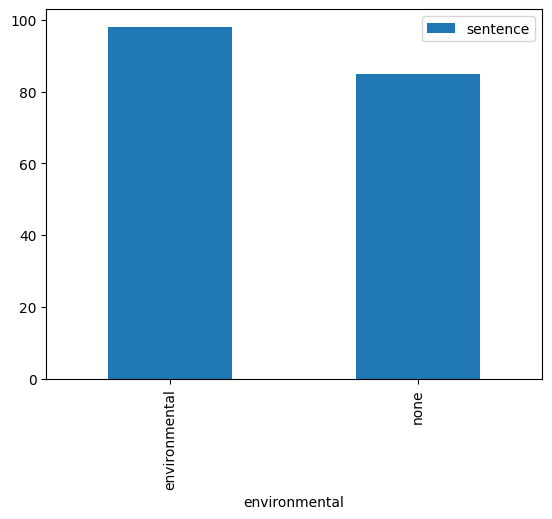

In [21]:
# It could also be interesting to look at the proporation of environmental sentences.
print(data_env_esfr_method.groupby("environmental").count())
data_env_esfr_method.groupby("environmental").count().plot(kind="bar")

In [22]:
# To load the model, we use the exact same steps as above.
model_name = "climatebert/distilroberta-base-climate-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name, max_len=512)
pipe_sent = pipeline("text-classification", model=model, tokenizer=tokenizer)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
# Use the model on the dataset.
sentiment_esfr_method = pipe_sent(sentences_esfr_method, padding=True, truncation=True)
# Add the sentiment to the DataFrame.
data_env_esfr_method["sentiment"] = [x["label"] for x in sentiment_esfr_method]

In [24]:
# Again, have a look at the outcome.
data_env_esfr_method[data_env_esfr_method["environmental"] == "environmental"]
# Click the first blue symbol that looks like a calculator in the top right of the dataframe to have a closer look.
# Audi seems to display a enthusiastic, pironeering spirit towards sustainability. This positive attitude is reflected as "opportunity".

,sentence,environmental,sentiment
0,OVERVIEW OF OUR APPROACH 3 3. METHODOLOGY DETA...,environmental,neutral
2,THE CASE FOR A TECHNOLOGY-ENABLING ESFR 12 APP...,environmental,neutral
3,Introduction This paper provides details of th...,environmental,neutral
4,The ESFR is an example of a climate-related di...,environmental,neutral
7,Although there have been external efforts to d...,environmental,neutral
...,...,...,...
143,The information provided in this document refl...,environmental,neutral
144,We do not undertake to update any of such info...,environmental,neutral
149,Factors that could cause JPMorgan Chase’s actu...,environmental,risk
181,Overview of Our Approach\t3. Methodology Detai...,environmental,neutral


sentiment
neutral        62
opportunity    34
risk            2
Name: environmental, dtype: int64


<Axes: xlabel='sentiment'>

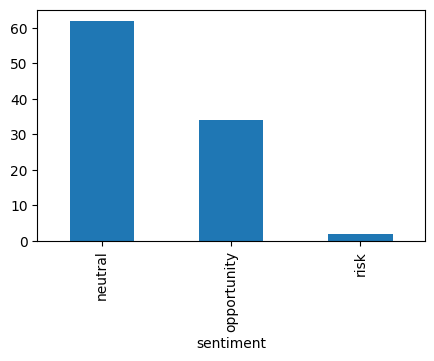

In [25]:
# Let's plot the distribution again.
print(data_env_esfr_method[data_env_esfr_method["environmental"] == "environmental"].groupby("sentiment").count()["environmental"])
data_env_esfr_method[data_env_esfr_method["environmental"] == "environmental"].groupby("sentiment").count()["environmental"].plot(kind = "bar", figsize=(5, 3))